# Radial conductivity
Here a simple example using the parameter class and showing a simple adjustment (fitting process) on the water outgoing flux given in the parameters file parameters.yml.

In [1]:
from openalea.hydroroot.main import hydroroot_flow, root_builder
from openalea.hydroroot.init_parameter import Parameters
from openalea.hydroroot.read_file import read_archi_data
from openalea.widgets.plantgl import PlantGL # notebook viewer 3D
from openalea.plantgl.algo.view import view # 2D view
from openalea.hydroroot.display import mtg_scene

## Reading the input parameters file

In [2]:
parameter = Parameters()
parameter.read_file('parameters.yml')

## Reading the architecture file and building the MTG

In [3]:
fname = parameter.archi['input_dir'] + parameter.archi['input_file'][0]
df = read_archi_data(fname) # replace 3 lines in example_parameter_class.ipynb

### building the MTG from the dataframe df
the output is the mtg, the primary root length, the total length and surface of the root, and the seed for the case of generated root here unsed


In [4]:
g, primary_length, total_length, surface, seed = root_builder(df = df, segment_length = parameter.archi['segment_length'],
            order_decrease_factor = parameter.archi['order_decrease_factor'], ref_radius = parameter.archi['ref_radius'])

## Performing the
Two steps:
- 1st run with conductivities given in parameters.yml and display water uptake before adjustement
- 2d the adjustment of k0 to fit parameter.exp['Jv'], done with a very simple Newton-Raphson loop.

In [5]:
axial_data = parameter.hydro['axial_conductance_data']
k0 = parameter.hydro['k0']
radial_data = ([0.0,0.2], [k0,k0]) # 1st list dist. to tip in cm, 2d list radial conductivity in microL/(s.MPa.m**2)
g, Keq, Jv = hydroroot_flow(g, segment_length = parameter.archi['segment_length'], psi_e = parameter.exp['psi_e'], 
                            psi_base = parameter.exp['psi_base'], axial_conductivity_data = axial_data, 
                            radial_conductivity_data = radial_data)

#### Display the local water uptake heatmap before adjustment

to reduce notebook size we use here a 2D view but you can use the openalea.widgets `PlantGL(s)` to display an interactive 3D view

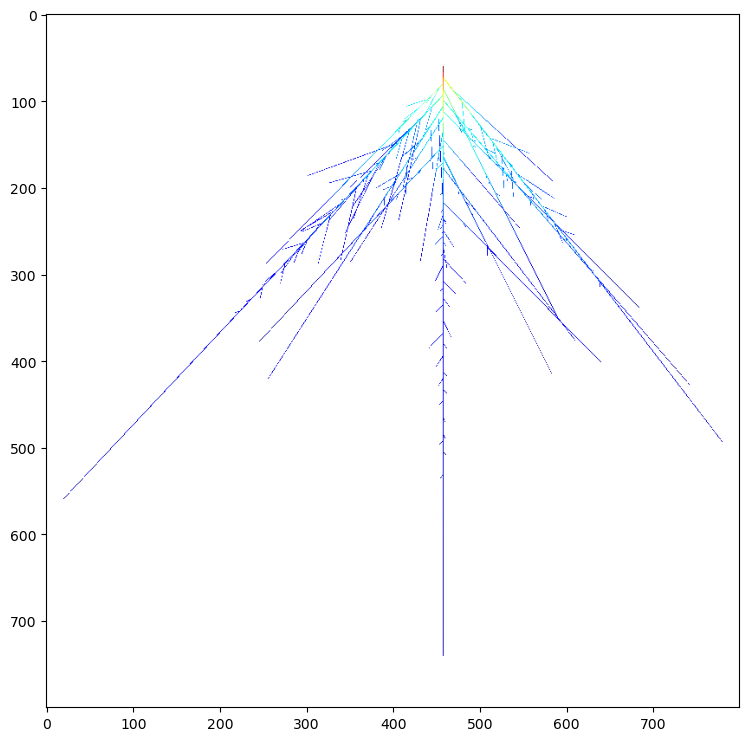

In [6]:
s = mtg_scene(g, prop_cmap = 'j') # create a scene from the mtg with the property j is the radial flux in ul/s
view(s) # use PlantGL(s) to display in 3D

#### Adjustement of radial conductivity

The adjustement is done by a simple Newton-Raphson scheme

In [7]:
k0_old = k0
F_old = (Jv - parameter.exp['Jv'])**2.0 # the objective function
k0 *= 0.9 # to initiate a simulation in the loop to compare with the previous one
eps = 1e-9 # the accuracy wanted
F = 1. # to launch the loop
# Newton-Raphson loop to get k0
while (F > eps):
    radial_data = ([0.0,0.2], [k0,k0])
    g, Keq, Jv = hydroroot_flow(g, segment_length = parameter.archi['segment_length'], psi_e = parameter.exp['psi_e'], 
                                psi_base = parameter.exp['psi_base'], axial_conductivity_data = axial_data, 
                                radial_conductivity_data = radial_data)

    F = (Jv - parameter.exp['Jv']) ** 2.0 # the objective function

    if abs(F) > eps:
        dfdk0 = (F - F_old) / (k0 - k0_old) # the derivative of F according to k0

        k0_old = k0

        k0 = k0_old - F / dfdk0 # new estimate
        while k0 < 1.0e-3:
            k0 = 0.5 * k0_old

        F_old = F

## Results

In [8]:
print('experimental Jv: ', parameter.exp['Jv'], 'simulated Jv: ', Jv, 'adjusted k: ', k0)

experimental Jv:  0.00723 simulated Jv:  0.007259718594573797 adjusted k:  48.09970642909217


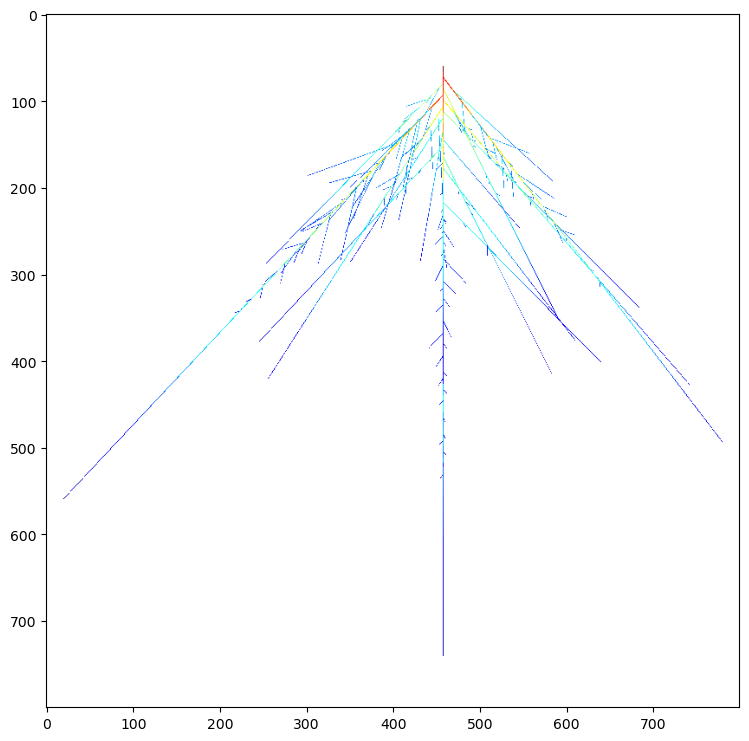

In [9]:
s = mtg_scene(g, prop_cmap = 'j') # create a scene from the mtg with the property j is the radial flux in ul/s
view(s) # use PlantGL(s) to display in 3D